In [42]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [44]:
np.random.seed(42)

n = 100000

data = pd.DataFrame({
    "Customer_ID": range(1, n+1),
    "Age": np.random.randint(18, 71, n),
    "Gender": np.random.choice(["Male", "Female"], n),
    "Tenure": np.random.randint(0, 11, n),
    "Balance": np.random.randint(0, 200001, n),
    "CreditScore": np.random.randint(300, 901, n),
    "EstimatedSalary": np.random.randint(10000, 150001, n),
    "NumOfProducts": np.random.randint(1, 5, n),
    "IsActiveMember": np.random.choice(["Yes", "No"], n)
})

In [45]:
def generate_churn(row):
    score = 0

    if row["CreditScore"] < 500:
        score += 2
    if row["Balance"] > 150000:
        score += 1
    if row["Tenure"] < 3:
        score += 2
    if row["IsActiveMember"] == "No":
        score += 2
    if row["NumOfProducts"] == 1:
        score += 1

    return 1 if score >= 4 else 0

data["Churn"] = data.apply(generate_churn, axis=1)

data.head()

,Customer_ID,Age,Gender,Tenure,Balance,CreditScore,EstimatedSalary,NumOfProducts,IsActiveMember,Churn
0,1,56,Female,3,138803,718,121992,4,No,0
1,2,69,Male,1,174102,534,125877,2,No,1
2,3,46,Female,10,90135,653,39062,2,Yes,0
3,4,32,Male,6,160284,787,66364,2,Yes,0
4,5,60,Female,6,24298,681,116045,2,Yes,0


In [46]:
data.info()
print(data.isnull().sum())
print("Duplicates:", data.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   Customer_ID      100000 non-null  int64 
 1   Age              100000 non-null  int64 
 2   Gender           100000 non-null  object
 3   Tenure           100000 non-null  int64 
 4   Balance          100000 non-null  int64 
 5   CreditScore      100000 non-null  int64 
 6   EstimatedSalary  100000 non-null  int64 
 7   NumOfProducts    100000 non-null  int64 
 8   IsActiveMember   100000 non-null  object
 9   Churn            100000 non-null  int64 
dtypes: int64(8), object(2)
memory usage: 7.6+ MB
Customer_ID        0
Age                0
Gender             0
Tenure             0
Balance            0
CreditScore        0
EstimatedSalary    0
NumOfProducts      0
IsActiveMember     0
Churn              0
dtype: int64
Duplicates: 0


In [47]:
data["Gender"] = data["Gender"].map({"Male": 0, "Female": 1})
data["IsActiveMember"] = data["IsActiveMember"].map({"No": 0, "Yes": 1})

In [48]:
print(data.describe())

print("Median:\n", data.median(numeric_only=True))
print("Mode:\n", data.mode().iloc[0])
print("Standard Deviation:\n", data.std(numeric_only=True))

         Customer_ID            Age         Gender         Tenure  \
count  100000.000000  100000.000000  100000.000000  100000.000000   
mean    50000.500000      43.984060       0.498910       4.988760   
std     28867.657797      15.251827       0.500001       3.163744   
min         1.000000      18.000000       0.000000       0.000000   
25%     25000.750000      31.000000       0.000000       2.000000   
50%     50000.500000      44.000000       0.000000       5.000000   
75%     75000.250000      57.000000       1.000000       8.000000   
max    100000.000000      70.000000       1.000000      10.000000   

             Balance    CreditScore  EstimatedSalary  NumOfProducts  \
count  100000.000000  100000.000000    100000.000000  100000.000000   
mean    99742.233670     599.942750     79959.021360       2.501980   
std     57670.541911     173.269555     40445.277417       1.117734   
min         0.000000     300.000000     10000.000000       1.000000   
25%     49819.000000   

In [49]:
print(data["Churn"].value_counts())

Churn
0    66860
1    33140
Name: count, dtype: int64


In [50]:
bins = [18, 25, 35, 45, 55, 65, 70]
labels = ["18-25", "25-35", "35-45", "45-55", "55-65", "65-70"]
data["Age_Group"] = pd.cut(data["Age"], bins=bins, labels=labels)

In [51]:
age_churn = pd.crosstab(data["Age_Group"], data["Churn"])
print(age_churn)

Churn          0     1
Age_Group             
18-25       8827  4332
25-35      12572  6339
35-45      12804  6325
45-55      12627  6200
55-65      12618  6263
65-70       6195  3082


In [52]:
gender_churn = pd.crosstab(data["Gender"], data["Churn"])
print(gender_churn)

Churn       0      1
Gender              
0       33441  16668
1       33419  16472


In [53]:
active_churn = pd.crosstab(data["IsActiveMember"], data["Churn"])
print(active_churn)

Churn               0      1
IsActiveMember              
0               22802  27305
1               44058   5835


In [54]:
product_churn = pd.crosstab(data["NumOfProducts"], data["Churn"])
print(product_churn)

Churn              0      1
NumOfProducts              
1              14606  10331
2              17297   7660
3              17552   7525
4              17405   7624


In [55]:
correlation = data.corr(numeric_only=True)
print(correlation)

                 Customer_ID       Age    Gender    Tenure   Balance  \
Customer_ID         1.000000 -0.000359  0.003538  0.004342 -0.000222   
Age                -0.000359  1.000000  0.001048 -0.000486 -0.002837   
Gender              0.003538  0.001048  1.000000 -0.000981 -0.003567   
Tenure              0.004342 -0.000486 -0.000981  1.000000  0.001169   
Balance            -0.000222 -0.002837 -0.003567  0.001169  1.000000   
CreditScore        -0.005602 -0.002580 -0.002401 -0.006829 -0.001880   
EstimatedSalary    -0.002574 -0.001827 -0.001989  0.003423  0.002050   
NumOfProducts      -0.002040 -0.003039  0.000371  0.000747 -0.002238   
IsActiveMember     -0.005706 -0.001007 -0.001245 -0.004641 -0.000833   
Churn               0.006932  0.000354 -0.002629 -0.354686  0.080727   

                 CreditScore  EstimatedSalary  NumOfProducts  IsActiveMember  \
Customer_ID        -0.005602        -0.002574      -0.002040       -0.005706   
Age                -0.002580        -0.001827  

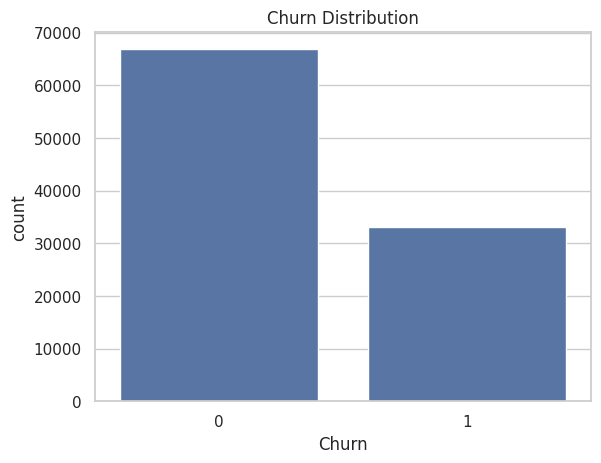

In [56]:
sns.countplot(x="Churn", data=data)
plt.title("Churn Distribution")
plt.show()

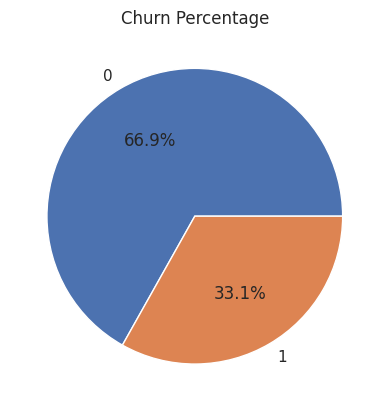

In [57]:
data["Churn"].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Churn Percentage")
plt.ylabel("")
plt.show()

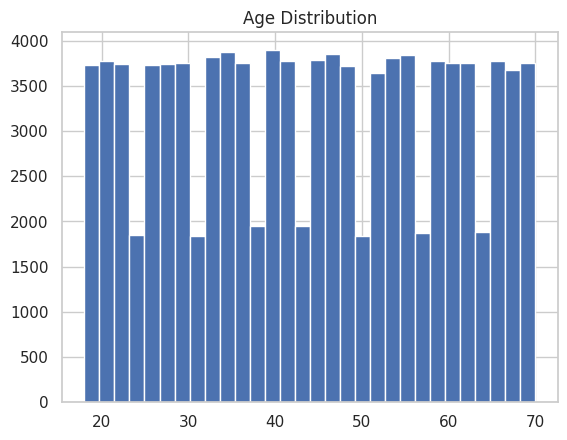

In [58]:
data["Age"].hist(bins=30)
plt.title("Age Distribution")
plt.show()

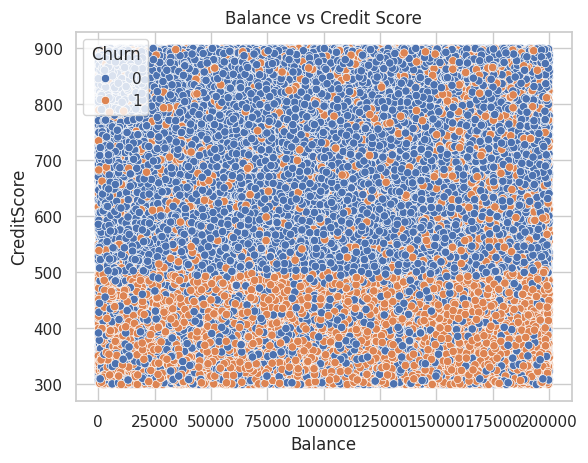

In [59]:
sns.scatterplot(x="Balance", y="CreditScore", hue="Churn", data=data)
plt.title("Balance vs Credit Score")
plt.show()

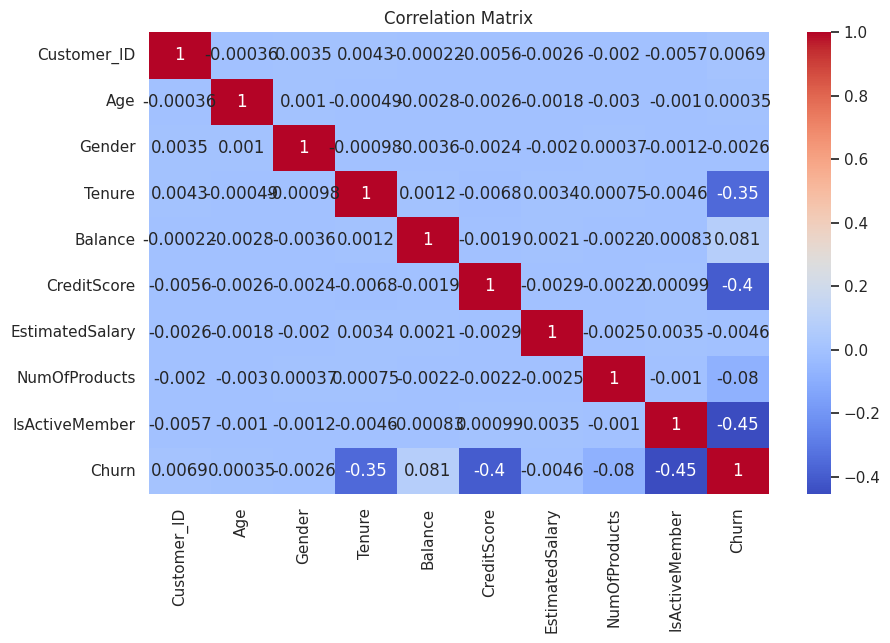

In [60]:
plt.figure(figsize=(10,6))
sns.heatmap(correlation, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [61]:
high_churn = data[data["Churn"] == 1]

print("High churn customers:", len(high_churn))
high_churn.head()

High churn customers: 33140


,Customer_ID,Age,Gender,Tenure,Balance,CreditScore,EstimatedSalary,NumOfProducts,IsActiveMember,Churn,Age_Group
1,2,69,0,1,174102,534,125877,2,0,1,65-70
5,6,25,0,4,118607,312,70553,2,0,1,18-25
13,14,70,1,1,172127,495,36126,2,1,1,65-70
15,16,57,0,1,71179,723,132562,1,0,1,55-65
17,18,20,0,2,137414,670,105630,1,0,1,18-25


In [62]:
data.to_csv("customer_churn_data.csv", index=False)